<a href="https://colab.research.google.com/github/KornelHajto/PEngineersML_msg/blob/main/pengineers_techtogether26_msg_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to the msg Techtogether 2026 task!

In this task you will get familiar with applied machine learning in network traffic management. Machine learning can be utilized in automatic pipelines, for example in an Intrusion Detection System (IDS) in the context of network anomaly detection.

In this Colab notebook you have a Python environment, where code can be run in the cloud. The dataset provided can be used for training and testing the machine learning model.

Your task is to finalize this machine learning solution, **find the mistakes** previously made by a colleague and **fine tune the model parameters** to achive at least **macro 0.75 F1 score** on the test split of the data.

**Your solution will only be accepted and scored, if you present this solution onsite, and reason the engineering decisions you made on the way.**

Understand the given machine learning model, gather the knowledge required too present the solution and answer questions.


Download the dataset

In [ ]:
!gdown 1iv8GYV9bnGV_yx0mDHzpeN0T1dS72XSX

Downloading...
From: https://drive.google.com/uc?id=1iv8GYV9bnGV_yx0mDHzpeN0T1dS72XSX
To: /content/train.csv
100% 19.1M/19.1M [00:00<00:00, 97.8MB/s]


Import dependecies

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, accuracy_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.utils import class_weight

In [ ]:
!pip install statsmodels

In [ ]:
!pip install imbalanced-learn

The dataset used in this task currently holds network traffic. This dataset is most useful for training supervised machine learning models capable of detecting and even classifying anomalies in the network. In this task scenario, we will simplify the problem, the objective is to achive a simple binary classification into benign and anomaly traffic.

In [ ]:
df = pd.read_csv('train.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total records: {len(df):,}")
print(f"Total features: {df.shape[1]}")

Dataset shape: (125973, 43)
Total records: 125,973
Total features: 43


In [ ]:
df.value_counts('label')

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


In [ ]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

columns_to_drop = ['difficulty', 'label']

X = df.drop(columns=columns_to_drop)
y = df['label']

X = pd.get_dummies(X)

benign_label = 'normal'
y = y.apply(lambda x: 0 if x == benign_label else 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=333, stratify=y
)

print(f"Training set size: {len(X_train):,} samples")

Training set size: 100,778 samples


In [ ]:
print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Original training set class distribution: {pd.Series(y_train).value_counts()}")


Original training set shape: (100778, 122), (100778,)
Original training set class distribution: label
0    53874
1    46904
Name: count, dtype: int64


### Multi-Class Classification with Multilayer Perceptron (MLP)

In [ ]:
# Install and import TensorFlow/Keras (if not already installed)
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import numpy as np

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


#### Data Preprocessing for MLP

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

smote = SMOTE(random_state=333)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

scaler_bin = StandardScaler()

X_train_scaled = scaler_bin.fit_transform(X_train_resampled)

X_test_scaled = scaler_bin.transform(X_test)

#### Build and Train MLP Model

In [ ]:
binary_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    #hidden layer
    Dense(64, activation='relu'),
    Dropout(0.3),

    #output layer
    Dense(1, activation='sigmoid')
])

#changed to adam instead of eva
binary_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training Binary Classification Model...")
history = binary_model.fit(
    X_train_scaled,
    y_train_resampled,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
print("Training complete!")

Training Binary Classification Model...
Epoch 1/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9757 - loss: 0.0723 - val_accuracy: 0.9872 - val_loss: 0.0427
Epoch 2/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9892 - loss: 0.0340 - val_accuracy: 0.9912 - val_loss: 0.0334
Epoch 3/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9912 - loss: 0.0283 - val_accuracy: 0.9911 - val_loss: 0.0308
Epoch 4/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9923 - loss: 0.0252 - val_accuracy: 0.9935 - val_loss: 0.0263
Epoch 5/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9926 - loss: 0.0227 - val_accuracy: 0.9935 - val_loss: 0.0260
Epoch 6/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9931 - loss: 0.0225 - val_accuracy: 0.9925 - val_loss: 0.0266
Epoch 7/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9933 - loss: 0.0212 - val_accuracy: 0.9935 - val_loss: 0.0257
Epoch 8/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms

#### Evaluate MLP Model Performance

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Binary Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.99      0.99     13469
 Anomaly (1)       0.99      0.99      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



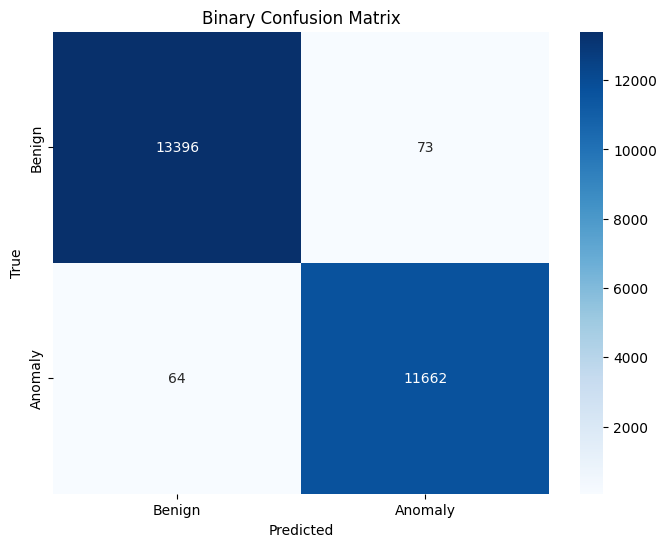

In [ ]:
y_pred_probs = binary_model.predict(X_test_scaled)

y_pred = (y_pred_probs > 0.5).astype(int)

print("\nBinary Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Anomaly (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Anomaly'],
            yticklabels=['Benign', 'Anomaly'])
plt.title('Binary Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

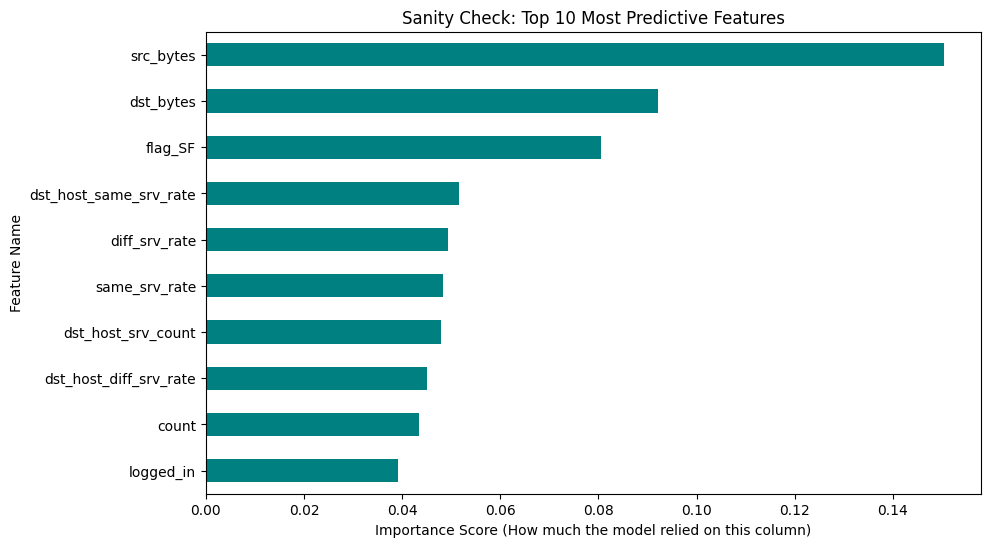

In [ ]:
# quick random forest
rf_diagnostic = RandomForestClassifier(n_estimators=100, random_state=333)
rf_diagnostic.fit(X_train_resampled, y_train_resampled)

importances = pd.Series(rf_diagnostic.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 6))
importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Sanity Check: Top 10 Most Predictive Features')
plt.xlabel('Importance Score (How much the model relied on this column)')
plt.ylabel('Feature Name')
plt.show()

# Precision-Recall curve

<Figure size 800x600 with 0 Axes>

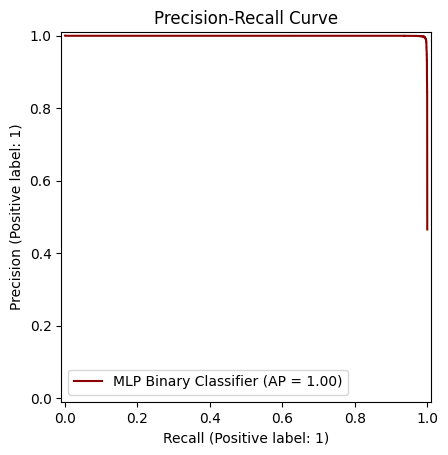

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

#Precision-Recall curve
plt.figure(figsize=(8, 6))
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_probs,
    name="MLP Binary Classifier",
    color="darkred"
)
_ = display.ax_.set_title("Precision-Recall Curve")
plt.show()